# King PSF Basic Demo

This notebook demonstrates the basic usage of the King point spread function (PSF) implementation in `kingmaker`. 

The King function is a mathematical model commonly used to describe the angular error distribution (PSF) of astronomical observations. It has two parameters:
- **α (alpha)**: Scale parameter controlling the width/spread of the distribution
- **β (beta)**: Shape parameter controlling the tail behavior (higher β = lighter tails)

## Contents:
1. **Basic KingPDF**: Understanding the PDF and effects of α and β parameters
2. **Comparison with Rayleigh distribution**: How King compares to simpler models
3. **InterpolatedKingPDF**: Speed improvements via pre-computed normalization
4. **Signal-subtracted likelihood**: Marginalization over right ascension

In [1]:
# Import required libraries
import numpy as np
from timeit import timeit
from matplotlib import pyplot as plt

# Import a Rayleigh distibution as a comparison
from scipy.stats import rayleigh

# Import kingmaker classes
from kingmaker.pdf import KingPDF, InterpolatedKingPDF
from kingmaker.distribution import _log10pi

# Set matplotlib style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')

## 1. Basic KingPDF Usage

The `KingPDF` class provides methods to evaluate the probability density function (PDF) and cumulative distribution function (CDF) of the King distribution.

Key methods:
- `pdf(x, alpha, beta)`: Evaluate the normalized PDF at angular separation x
- `cdf(x, alpha, beta)`: Evaluate the CDF 
- `norm(alpha, beta)`: Get the normalization constant
- `marginalize(dec, alpha, beta)`: Marginalize over right ascension for signal subtraction

Let's create a KingPDF instance with full-sphere coverage (angular_cutoff = π).

In [2]:
# Create KingPDF instance with full sphere coverage
angular_cutoff = np.pi  # 180 degrees
k = KingPDF(angular_cutoff=angular_cutoff)

print(f"KingPDF initialized with angular cutoff: {np.degrees(angular_cutoff):.1f} degrees")

KingPDF initialized with angular cutoff: 180.0 degrees


### 1a. Effect of α (alpha) parameter

The alpha parameter controls the width/scale of the distribution. Larger alpha means a wider PSF (worse angular resolution).

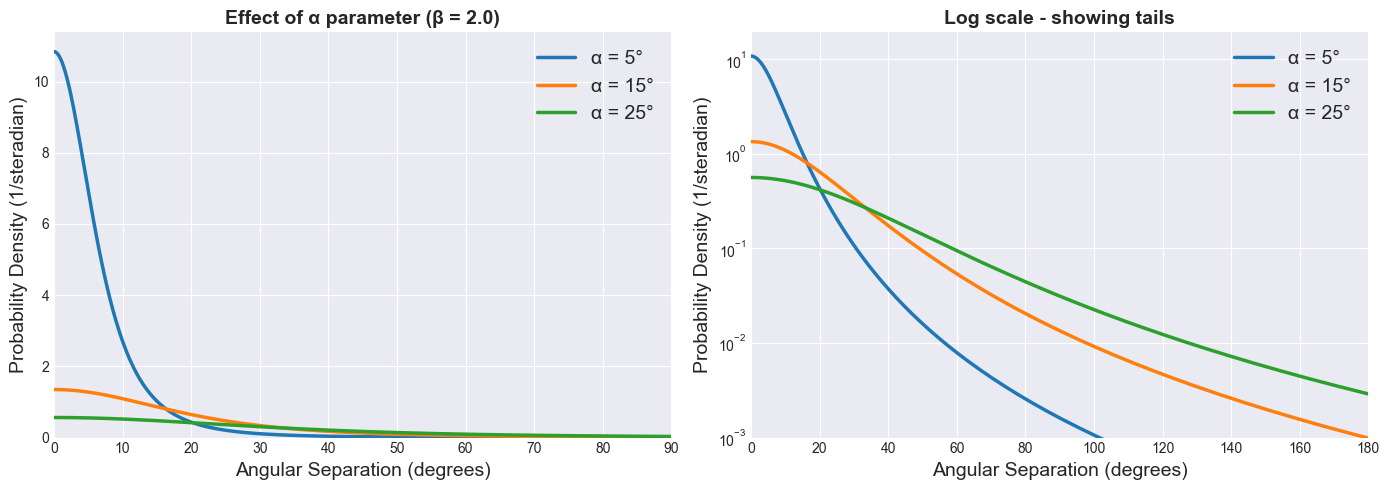

Observation: Larger α values create wider, flatter distributions (worse angular resolution)


In [3]:
# Demonstrate the effect of alpha on the PDF
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Angular separation values to evaluate (in radians)
x = np.logspace(-5, np.log10(np.pi), 500)

# Test different alpha values (in degrees, converted to radians)
alphas = np.deg2rad([5, 15, 25])
beta_fixed = 2.0  # Keep beta constant

for alpha in alphas:
    pdf = k.pdf(x, alpha, beta_fixed)
    ax1.plot(np.degrees(x), pdf, 
             label=f'α = {np.degrees(alpha):.0f}°', 
             linewidth=2.5)

ax1.set_xlabel('Angular Separation (degrees)', fontsize=14)
ax1.set_ylabel('Probability Density (1/steradian)', fontsize=14)
ax1.set_title(f'Effect of α parameter (β = {beta_fixed})', fontsize=14, fontweight='bold')
ax1.set_xlim(0, 90)
ax1.set_ylim(ymin=0)
ax1.legend(fontsize=14)
ax1.grid(alpha=1)

# Log-scale version to see the tails
for alpha in alphas:
    pdf = k.pdf(x, alpha, beta_fixed)
    ax2.semilogy(np.degrees(x), pdf, 
                 label=f'α = {np.degrees(alpha):.0f}°', 
                 linewidth=2.5)

ax2.set_xlabel('Angular Separation (degrees)', fontsize=14)
ax2.set_ylabel('Probability Density (1/steradian)', fontsize=14)
ax2.set_title('Log scale - showing tails', fontsize=14, fontweight='bold')
ax2.set_xlim(0, 180)
ax2.set_ylim(1e-3, None)
ax2.legend(fontsize=14)
ax2.grid(alpha=1)

plt.tight_layout()
plt.show()

print("Observation: Larger α values create wider, flatter distributions (worse angular resolution)")

### 1b. Effect of β (beta) parameter

The beta parameter controls the tail behavior. Higher beta values result in steeper/lighter tails, while lower values create heavier tails.

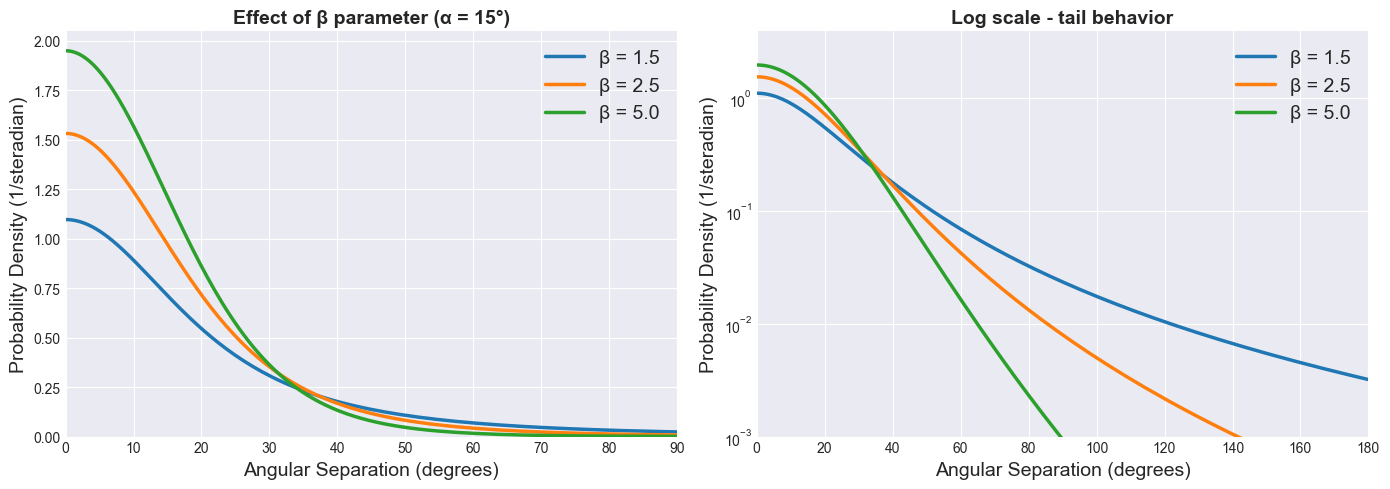

Observation: Higher β values create sharper peaks with steeper/lighter tails
             Lower β values create heavier tails (more outlier events)


In [4]:
# Demonstrate the effect of beta on the PDF
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Test different beta values
alpha_fixed = np.deg2rad(15)  # Keep alpha constant
betas = [1.5, 2.5, 5.0]

for beta in betas:
    pdf = k.pdf(x, alpha_fixed, beta)
    ax1.plot(np.degrees(x), pdf, 
             label=f'β = {beta:.1f}', 
             linewidth=2.5)

ax1.set_xlabel('Angular Separation (degrees)', fontsize=14)
ax1.set_ylabel('Probability Density (1/steradian)', fontsize=14)
ax1.set_title(f'Effect of β parameter (α = {np.degrees(alpha_fixed):.0f}°)', fontsize=14, fontweight='bold')
ax1.set_xlim(0, 90)
ax1.set_ylim(ymin=0)
ax1.legend(fontsize=14)
ax1.grid(alpha=1)

# Log-scale to emphasize tail differences
for beta in betas:
    pdf = k.pdf(x, alpha_fixed, beta)
    ax2.semilogy(np.degrees(x), pdf, 
                 label=f'β = {beta:.1f}', 
                 linewidth=2.5)

ax2.set_xlabel('Angular Separation (degrees)', fontsize=14)
ax2.set_ylabel('Probability Density (1/steradian)', fontsize=14)
ax2.set_title('Log scale - tail behavior', fontsize=14, fontweight='bold')
ax2.set_xlim(0, 180)
ax2.set_ylim(1e-3, None)
ax2.legend(fontsize=14)
ax2.grid(alpha=1)

plt.tight_layout()
plt.show()

print("Observation: Higher β values create sharper peaks with steeper/lighter tails")
print("             Lower β values create heavier tails (more outlier events)")

### 1c. Cumulative Distribution Function (CDF)

The CDF tells us the probability that an event is within a given angular distance. This is useful for calculating containment radii.

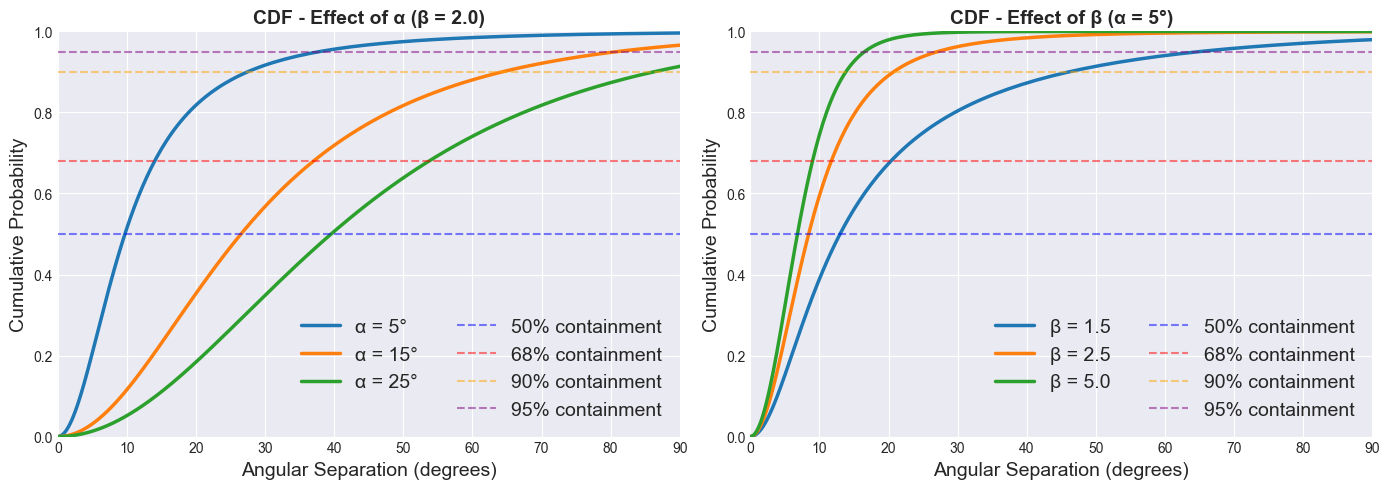

In [5]:
# Plot CDFs for different parameters
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Effect of alpha on CDF
alphas = np.deg2rad([5, 15, 25])
beta_fixed = 2.0

for alpha in alphas:
    cdf = k.cdf(x, alpha, beta_fixed)
    ax1.plot(np.degrees(x), cdf, 
             label=f'α = {np.degrees(alpha):.0f}°', 
             linewidth=2.5)

# Add horizontal lines for common containment levels
ax1.axhline(-1, color=None, alpha=0, linestyle='--', label=' ')
for level, color in [(0.5, 'blue'), (0.68, 'red'), (0.90, 'orange'), (0.95, 'purple')]:
    ax1.axhline(level, color=color, linestyle='--', alpha=0.5, linewidth=1.5,
                label=f'{int(level*100)}% containment')

ax1.set_xlabel('Angular Separation (degrees)', fontsize=14)
ax1.set_ylabel('Cumulative Probability', fontsize=14)
ax1.set_title(f'CDF - Effect of α (β = {beta_fixed})', fontsize=14, fontweight='bold')
ax1.set_xlim(0, 90)
ax1.set_ylim(0, 1)
ax1.legend(ncol=2, fontsize=14)
ax1.grid(alpha=1)

# Effect of beta on CDF
alpha_fixed = np.deg2rad(5)
betas = [1.5, 2.5, 5.0]

for beta in betas:
    cdf = k.cdf(x, alpha_fixed, beta)
    ax2.plot(np.degrees(x), cdf, 
             label=f'β = {beta:.1f}', 
             linewidth=2.5)

# Add horizontal lines for common containment levels
ax2.axhline(-1, color=None, alpha=0, linestyle='--', label=' ')
for level, color in [(0.5, 'blue'), (0.68, 'red'), (0.90, 'orange'), (0.95, 'purple')]:
    ax2.axhline(level, color=color, linestyle='--', alpha=0.5, linewidth=1.5,
                label=f'{int(level*100)}% containment')

ax2.set_xlabel('Angular Separation (degrees)', fontsize=14)
ax2.set_ylabel('Cumulative Probability', fontsize=14)
ax2.set_title(f'CDF - Effect of β (α = {np.degrees(alpha_fixed):.0f}°)', fontsize=14, fontweight='bold')
ax2.set_xlim(0, 90)
ax2.set_ylim(0, 1)
ax2.legend(ncol=2, fontsize=14)
ax2.grid(alpha=1)

plt.tight_layout()
plt.show()

## 2. Comparison with Rayleigh Distribution

The Rayleigh distribution is a simpler 1-parameter model often used for angular errors. Let's compare it with the King distribution.

The Rayleigh PDF in scipy has the form: `f(x) = (x/σ²) * exp(-x²/(2σ²))` for x ≥ 0

For spherical coordinates, we need to include the sin(θ) Jacobian.

/var/folders/xz/hwb936c16hv507dyhyngvbhm0000gn/T/ipykernel_39521/2060252066.py:27: RuntimeWarning: invalid value encountered in divide
  rayleigh_pdf = rayleigh.pdf(x_rad, scale=rayleigh_scale) / (2 * np.pi * np.sin(x_rad))


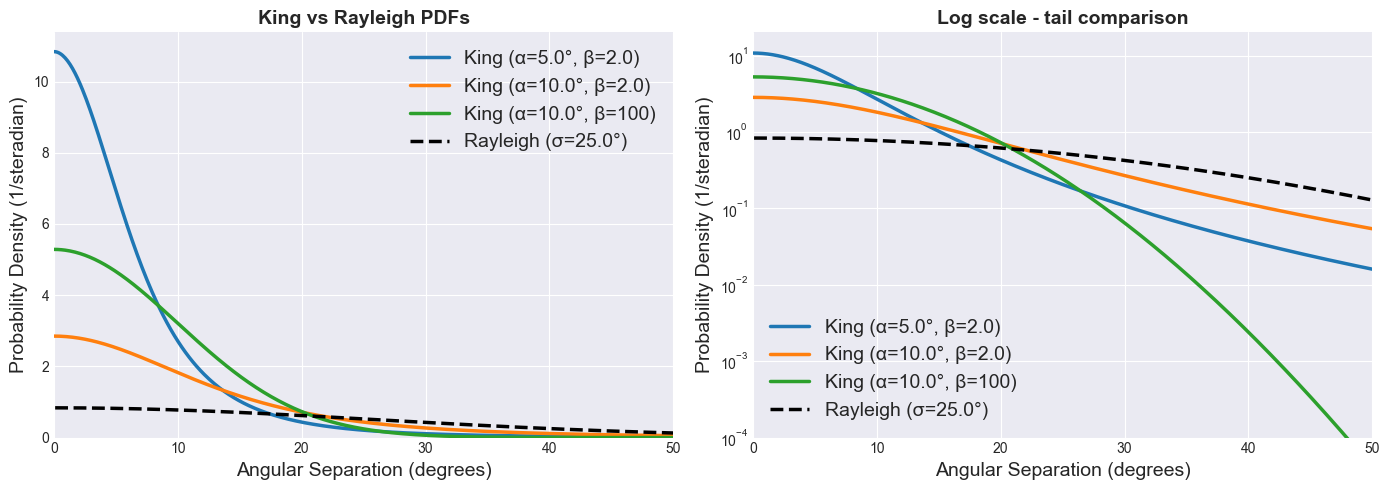

Observation: King distribution allows more weight in the tails than Rayleigh.
             The β parameter allows control of tail behavior
             The Rayleigh is a limiting case of the King where β -> inf
             Rayleigh has exponential tails, King can be adjusted via β


In [6]:
# Compare King distribution with Rayleigh distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Choose King parameters
alphas = [np.deg2rad(5), np.deg2rad(10), np.deg2rad(10)]
betas = [2.0, 2.0, 100]

# For Rayleigh, we'll use a scale parameter that roughly matches the King width
# The Rayleigh scale relates to the King alpha approximately
rayleigh_scale = alpha  

# Evaluate both distributions
x_deg = np.linspace(0, 50, 500)
x_rad = np.radians(x_deg)

# Plot PDFs
for alpha, beta in zip(alphas, betas):
    king_pdf = k.pdf(x_rad, alpha, beta)
    ax1.plot(x_deg, king_pdf, linewidth=2.5, label=f'King (α={np.degrees(alpha):.1f}°, β={beta})',)

# Rayleigh PDF for angular errors
# scipy's rayleigh.pdf gives a 1D PDF in units of 1/radian
# We need to convert to units of 1/steradian for proper comparison
# The solid angle element is dΩ = 2π sin(θ) dθ
# So: PDF(1/sr) = PDF(1/rad) / (dΩ/dθ) = rayleigh.pdf(θ) / (2π sin(θ))
# Note: This is already normalized because ∫ rayleigh_pdf_sr * dΩ = ∫ rayleigh_pdf_linear * dθ = 1
rayleigh_pdf = rayleigh.pdf(x_rad, scale=rayleigh_scale) / (2 * np.pi * np.sin(x_rad))
ax1.plot(x_deg, rayleigh_pdf, linewidth=2.5, label=f'Rayleigh (σ={np.degrees(rayleigh_scale):.1f}°)', 
         color='black', linestyle='--')

ax1.set_xlabel('Angular Separation (degrees)', fontsize=14)
ax1.set_ylabel('Probability Density (1/steradian)', fontsize=14)
ax1.set_title('King vs Rayleigh PDFs', fontsize=14, fontweight='bold')
ax1.legend(fontsize=14)
ax1.grid(alpha=1.0)
ax1.set_xlim(0, 50)
ax1.set_ylim(ymin=0)

# Log scale to see differences in tails
for alpha, beta in zip(alphas, betas):
    king_pdf = k.pdf(x_rad, alpha, beta)
    ax2.semilogy(x_deg, king_pdf, linewidth=2.5, label=f'King (α={np.degrees(alpha):.1f}°, β={beta})')

ax2.semilogy(x_deg, rayleigh_pdf, linewidth=2.5, label=f'Rayleigh (σ={np.degrees(rayleigh_scale):.1f}°)', 
             color='black', linestyle='--')
ax2.set_xlabel('Angular Separation (degrees)', fontsize=14)
ax2.set_ylabel('Probability Density (1/steradian)', fontsize=14)
ax2.set_title('Log scale - tail comparison', fontsize=14, fontweight='bold')
ax2.legend(fontsize=14)
ax2.grid(alpha=1.0)
ax2.set_xlim(0, 50)
ax2.set_ylim(1e-4, None)

plt.tight_layout()
plt.show()

print("Observation: King distribution allows more weight in the tails than Rayleigh.")
print("             The β parameter allows control of tail behavior")
print("             The Rayleigh is a limiting case of the King where β -> inf")
print("             Rayleigh has exponential tails, King can be adjusted via β")

## 3. InterpolatedKingPDF - Speed Improvements

The `InterpolatedKingPDF` class pre-computes normalization constants on a grid and uses 2D interpolation. This provides significant speed improvements when evaluating the PDF many times.

Memory usage: The interpolation grid uses ~3.2 MB (200 × 200 grid in log10 space)
Speed gain: 10-100× faster depending on the number of evaluations

In [7]:
# Create an InterpolatedKingPDF instance
ik = InterpolatedKingPDF(angular_cutoff=angular_cutoff)

print("InterpolatedKingPDF initialized")
print(f"  Alpha grid: {len(ik.points_alpha)} points from {np.degrees(ik.points_alpha.min()):.2e}° to {np.degrees(ik.points_alpha.max()):.2f}°")
print(f"  Beta grid: {len(ik.points_beta)} points from {ik.points_beta.min():.2f} to {ik.points_beta.max():.2f}")
print(f"  Memory usage: {(ik.points_alpha.nbytes + ik.points_beta.nbytes + ik.log10_grid_norms.nbytes)/1024**2:.2f} MB")

InterpolatedKingPDF initialized
  Alpha grid: 200 points from 5.73e-03° to 184.19°
  Beta grid: 200 points from 1.00 to 10.00
  Memory usage: 0.31 MB


### 3a. Accuracy Comparison

First, let's verify that the interpolated version is accurate compared to the direct calculation.

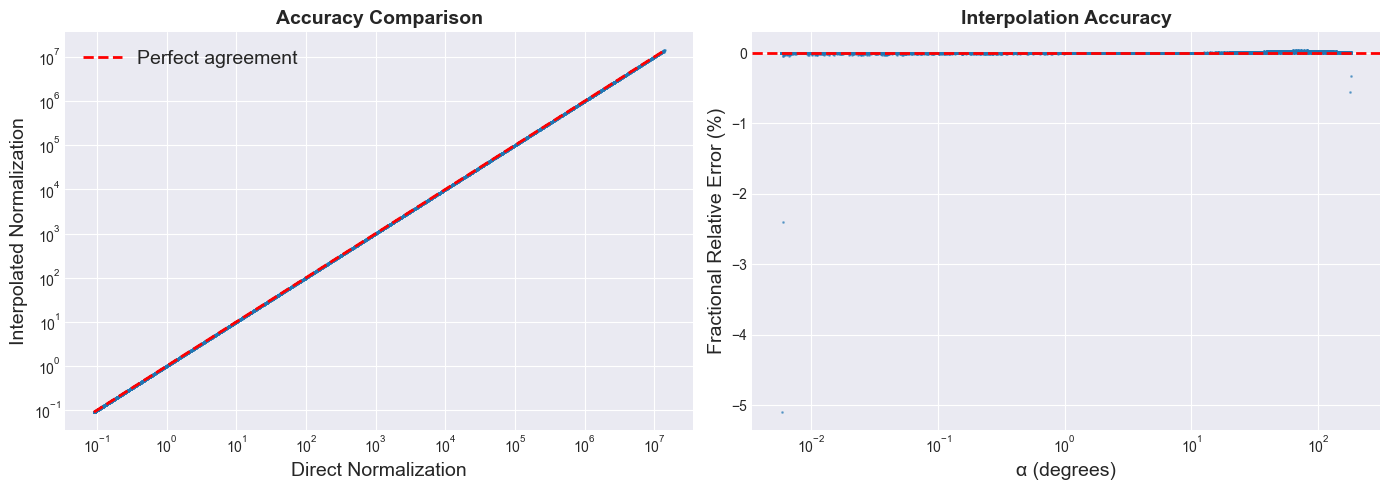

Relative error statistics:
  Mean: 0.0022%
  Std:  0.057%
 99.9% range [ 9e-10,  0.04]
  Max:  5.1%

Interpolation is highly accurate (< 0.1% error for most cases)


In [9]:
# Test accuracy of interpolation
n_test = 10000
alpha_test = np.logspace(np.log10(ik.points_alpha.min()), 
                         np.log10(ik.points_alpha.max()), n_test)
beta_test = np.random.uniform(ik.points_beta.min(), ik.points_beta.max(), n_test)

# Compute normalizations both ways
norm_direct = k.norm(alpha_test, beta_test)
norm_interp = ik.norm(alpha_test, beta_test)

# Calculate relative error
rel_error = (norm_interp - norm_direct) / norm_direct

# Plot comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot of values
ax1.scatter(norm_direct, norm_interp, s=1, alpha=0.5)
ax1.plot([norm_direct.min(), norm_direct.max()], 
         [norm_direct.min(), norm_direct.max()], 
         'r--', linewidth=2, label='Perfect agreement')
ax1.set_xlabel('Direct Normalization', fontsize=14)
ax1.set_ylabel('Interpolated Normalization', fontsize=14)
ax1.set_title('Accuracy Comparison', fontsize=14, fontweight='bold')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.legend(fontsize=14)
ax1.grid(alpha=1.0)

# Relative error vs alpha
ax2.scatter(np.degrees(alpha_test), rel_error*100, s=1, alpha=0.5)
ax2.axhline(0, color='red', linestyle='--', linewidth=2)
ax2.set_xlabel('α (degrees)', fontsize=14)
ax2.set_ylabel('Fractional Relative Error (%)', fontsize=14)
ax2.set_title('Interpolation Accuracy', fontsize=14, fontweight='bold')
ax2.set_xscale('log')
ax2.set_yscale
ax2.grid(alpha=1.0)

plt.tight_layout()
plt.show()

print(f"Relative error statistics:")
print(f"  Mean: {rel_error.mean()*100:.2}%")
print(f"  Std:  {rel_error.std()*100:.2}%")
rel_err_999percent_range = np.percentile(np.abs(rel_error), [0.005, 99.995])
print(f" 99.9% range [{rel_err_999percent_range[0]: 2.1}, {rel_err_999percent_range[1]: 2.1}]")
print(f"  Max:  {np.abs(rel_error).max()*100:.2}%")
print(f"\nInterpolation is highly accurate (< 0.1% error for most cases)")

### 3b. Speed Benchmark

Now let's measure the speedup from using interpolation.

Benchmarking norm() evaluation speed...
n_points | Direct (ms) | Interp (ms) | Speedup
-------------------------------------------------------
       1 |      0.0171 |      0.0613 |     0.3x
       5 |      0.0819 |      0.0608 |     1.3x
      10 |      0.1623 |      0.0618 |     2.6x
      50 |      0.8210 |      0.0649 |    12.6x
     100 |      1.6206 |      0.0654 |    24.8x
     500 |      8.0935 |      0.0854 |    94.7x
    1000 |     16.1390 |      0.1050 |   153.7x
    5000 |     80.7497 |      0.2079 |   388.4x
   10000 |    161.3868 |      0.3058 |   527.8x
   50000 |    807.8985 |      1.1427 |   707.0x
  100000 |   1614.3983 |      2.1579 |   748.1x


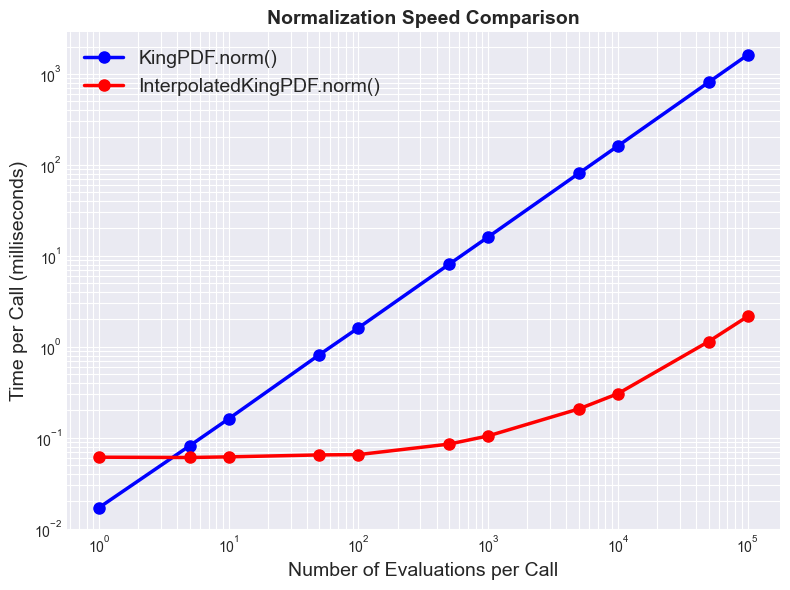

In [10]:
# Speed benchmark for norm() method
# Test with different numbers of simultaneous evaluations
n_points = [1, 5, 10, 50, 100, 500, 1000, 5000, 10000, 50000, 100000]
time_direct = []
time_interp = []

print("Benchmarking norm() evaluation speed...")
print("n_points | Direct (ms) | Interp (ms) | Speedup")
print("-" * 55)

for n in n_points:
    n_trials = max(1, int(1e5 // n))  # Fewer trials for larger n
    
    # Generate random test data
    alpha = np.random.uniform(ik.points_alpha.min(), ik.points_alpha.max(), n)
    beta = np.random.uniform(ik.points_beta.min(), ik.points_beta.max(), n)
    
    # Time direct method
    t_direct = timeit(lambda: k.norm(alpha, beta), number=n_trials) / n_trials * 1000
    time_direct.append(t_direct)
    
    # Time interpolated method
    t_interp = timeit(lambda: ik.norm(alpha, beta), number=n_trials) / n_trials * 1000
    time_interp.append(t_interp)
    
    speedup = t_direct / t_interp
    print(f"{n:8d} | {t_direct:11.4f} | {t_interp:11.4f} | {speedup:7.1f}x")

# Plot results
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(n_points, time_direct, 'o-', linewidth=2.5, markersize=8, 
        label='KingPDF.norm()', color='blue')
ax.plot(n_points, time_interp, 'o-', linewidth=2.5, markersize=8, 
        label='InterpolatedKingPDF.norm()', color='red')
ax.set_xlabel('Number of Evaluations per Call', fontsize=14)
ax.set_ylabel('Time per Call (milliseconds)', fontsize=14)
ax.set_title('Normalization Speed Comparison', fontsize=14, fontweight='bold')
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend(fontsize=14, loc='upper left')
ax.grid(alpha=1.0, which='both')
plt.tight_layout()
plt.show()

## 4. Signal-Subtracted Likelihood

The `marginalize()` method computes the PDF marginalized over right ascension. This is exactly equivalent to the standard "signal subtracted likelihood" used in many analyses. 

In signal-subtraction, we admit that our scrambled data PDFs used for background will have some non-zero signal contamination. In order to quantify and correct for this, we must calculate the signal contribution in the same space used for the background PDF. The background PDF is built as a 1d spline in reconstructed declination, so it is effectively marginalizing over right ascension.

The method integrates the 2D King PDF over RA using adaptive binning to produce a 1D profile in sin(declination). We can then weight and sum these marginalized PDFs for each signal event to model the contribution of signal to the background PDF.

**Use case**: In likelihood-based neutrino source searches, this marginalized PDF is used for "signal subtraction" - accounting for the expected spatial distribution of signal events when computing the background-only likelihood.

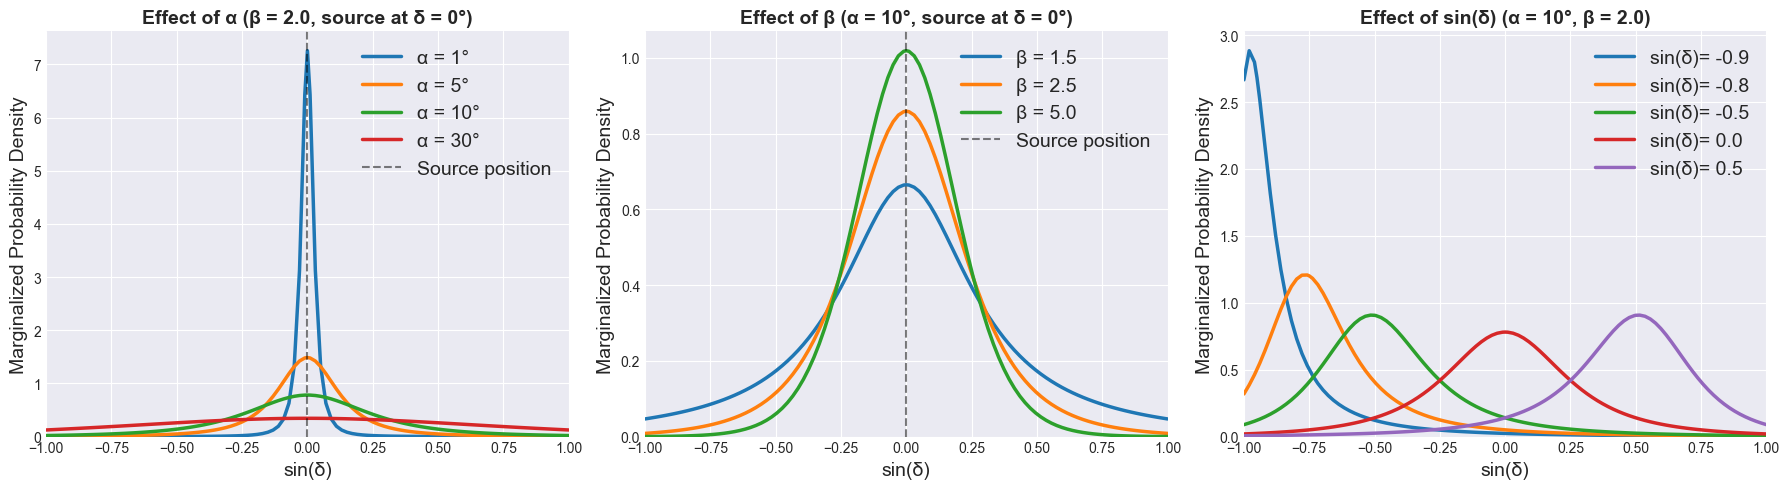

Observation: The marginalized PDF shows how the King PSF
             spreads signal events across declination bands
             This is used in likelihood calculations for point source searches


In [11]:
# Demonstrate marginalization over RA
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Set the number of points to evaluate the marginalization term.
# These will be evenly spread between -1 <= sindec <= 1
nbins = 100

#------------------------------------
# Effect of alpha values
#------------------------------------
alphas = np.deg2rad([1, 5, 10, 30])
beta_fixed = 2.0
dec_source = 0.0  # Equator

for alpha in alphas:
    sindec_bins, pdf_marginalized = k.marginalize(dec_source, alpha, beta_fixed, nbins=nbins)
    ax1.plot(sindec_bins, pdf_marginalized, 
             label=f'α = {np.degrees(alpha):.0f}°', 
             linewidth=2.5)

ax1.set_xlabel('sin(δ)', fontsize=14)
ax1.set_ylabel('Marginalized Probability Density', fontsize=14)
ax1.set_title(f'Effect of α (β = {beta_fixed}, source at δ = {np.degrees(dec_source):.0f}°)', 
              fontsize=14, fontweight='bold')
ax1.set_xlim(-1, 1)
ax1.set_ylim(ymin=0)
ax1.axvline(np.sin(dec_source), color='black', linestyle='--', alpha=0.5, linewidth=1.5,
            label='Source position')
ax1.legend(fontsize=14)
ax1.grid(alpha=1.0)

#------------------------------------
# Effect of beta values
#------------------------------------
alpha_fixed = np.deg2rad(10)
betas = [1.5, 2.5, 5.0]
dec_source = 0.0  # Equator

for beta in betas:
    sindec_bins, pdf_marginalized = k.marginalize(dec_source, alpha_fixed, beta, nbins=nbins)
    ax2.plot(sindec_bins, pdf_marginalized, 
             label=f'β = {beta:.1f}', 
             linewidth=2.5)

ax2.set_xlabel('sin(δ)', fontsize=14)
ax2.set_ylabel('Marginalized Probability Density', fontsize=14)
ax2.set_title(f'Effect of β (α = {np.degrees(alpha_fixed):.0f}°, source at δ = {np.degrees(dec_source):.0f}°)', 
              fontsize=14, fontweight='bold')
ax2.set_xlim(-1, 1)
ax2.set_ylim(ymin=0)
ax2.axvline(np.sin(dec_source), color='black', linestyle='--', alpha=0.5, linewidth=1.5,
            label='Source position')
ax2.legend(fontsize=14)
ax2.grid(alpha=1.)

#------------------------------------
# Effect of declination
#------------------------------------
alpha_fixed = np.deg2rad(10)
beta_fixed = 2.0
dec_sources = np.arcsin([-0.95, -0.75, -0.5, 0, 0.5])

for dec_source in dec_sources:
    sindec_bins, pdf_marginalized = k.marginalize(dec_source, alpha_fixed, beta_fixed, nbins=nbins)
    ax3.plot(sindec_bins, pdf_marginalized, 
             label=f'sin(δ)= {np.sin(dec_source):.1f}', 
             linewidth=2.5)

ax3.set_xlabel('sin(δ)', fontsize=14)
ax3.set_ylabel('Marginalized Probability Density', fontsize=14)
ax3.set_title(f'Effect of sin(δ) (α = {np.degrees(alpha_fixed):.0f}°, β = {beta_fixed})', 
              fontsize=14, fontweight='bold')
ax3.set_xlim(-1, 1)
ax3.set_ylim(ymin=0)

ax3.legend(fontsize=14)
ax3.grid(alpha=1.)

plt.tight_layout()
plt.show()

print("Observation: The marginalized PDF shows how the King PSF")
print("             spreads signal events across declination bands")
print("             This is used in likelihood calculations for point source searches")

### 4a. Marginalization Speed Comparison

The interpolated version also speeds up marginalization calculations. The marginalize calculation internally removes RA/declination bins with negligible weight. This introduces some dependence on values used for alpha and beta.

Benchmarking marginalize() evaluation speed...
α (deg) | Direct (ms) | Interp (ms) | Speedup
-------------------------------------------------------
   0.10 |      270.95 |        0.82 |   328.5x
   0.20 |      180.55 |        0.70 |   258.2x
   0.40 |      137.85 |        0.62 |   221.1x
   0.79 |      115.21 |        0.57 |   202.9x
   1.58 |      107.28 |        0.55 |   195.5x
   3.16 |      157.23 |        0.63 |   248.1x
   6.31 |      160.85 |        0.65 |   245.7x
  12.59 |       93.95 |        0.53 |   178.0x
  25.12 |       48.27 |        0.40 |   120.1x
  50.12 |       24.79 |        0.34 |    73.0x
 100.00 |       13.05 |        0.30 |    43.2x


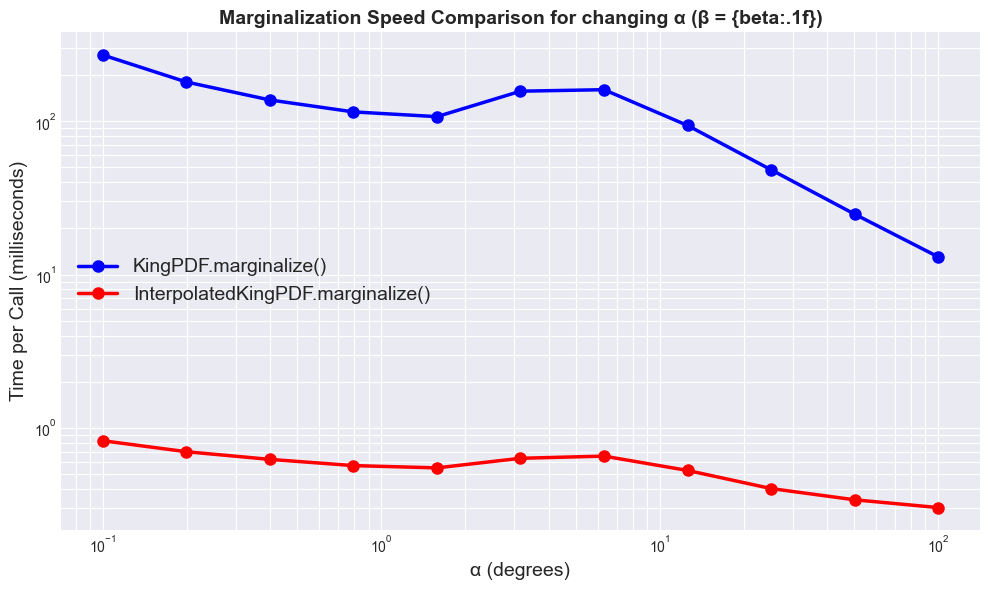


Speedup factor: 202.9x (median)


In [12]:
# Speed benchmark for marginalize() method
alphas_test = np.deg2rad(np.logspace(-1, 2, 11))  # 0.1° to 100°
beta = 3.0
time_direct_marg = []
time_interp_marg = []

print("Benchmarking marginalize() evaluation speed...")
print("α (deg) | Direct (ms) | Interp (ms) | Speedup")
print("-" * 55)

for alpha in alphas_test:
    n_trials = 10
    
    # Time direct method
    t_direct = timeit(lambda: k.marginalize(0, alpha, beta), number=n_trials) / n_trials * 1000
    time_direct_marg.append(t_direct)
    
    # Time interpolated method
    t_interp = timeit(lambda: ik.marginalize(0, alpha, beta), number=n_trials) / n_trials * 1000
    time_interp_marg.append(t_interp)
    
    speedup = t_direct / t_interp
    print(f"{np.degrees(alpha):7.2f} | {t_direct:11.2f} | {t_interp:11.2f} | {speedup:7.1f}x")

# Plot results
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(np.degrees(alphas_test), time_direct_marg, 'o-', linewidth=2.5, markersize=8,
        label='KingPDF.marginalize()', color='blue')
ax.plot(np.degrees(alphas_test), time_interp_marg, 'o-', linewidth=2.5, markersize=8,
        label='InterpolatedKingPDF.marginalize()', color='red')
ax.set_xlabel('α (degrees)', fontsize=14)
ax.set_ylabel('Time per Call (milliseconds)', fontsize=14)
ax.set_title('Marginalization Speed Comparison for changing α (β = {beta:.1f})', fontsize=14, fontweight='bold')
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend(fontsize=14)
ax.grid(alpha=1, which='both')
plt.tight_layout()
plt.show()

print(f"\nSpeedup factor: {np.median([time_direct_marg[i]/time_interp_marg[i] for i in range(len(alphas_test))]):.1f}x (median)")

Benchmarking marginalize() evaluation speed...
β | Direct (ms) | Interp (ms) | Speedup
-------------------------------------------------------
   1.00 |     1699.47 |        3.87 |   439.4x
   1.50 |     1638.68 |        3.71 |   441.5x
   2.00 |      541.36 |        1.43 |   378.0x
   2.50 |      207.46 |        0.75 |   276.6x
   3.00 |      110.74 |        0.57 |   195.4x
   3.50 |       74.66 |        0.46 |   163.3x
   4.00 |       57.17 |        0.44 |   128.9x
   4.50 |       47.12 |        0.39 |   121.8x
   5.00 |       40.96 |        0.39 |   104.6x
   5.50 |       37.19 |        0.38 |    98.1x
   6.00 |       34.88 |        0.39 |    89.2x
   6.50 |       32.22 |        0.37 |    86.0x
   7.00 |       30.80 |        0.36 |    85.0x
   7.50 |       29.46 |        0.35 |    83.3x
   8.00 |       28.91 |        0.36 |    80.4x
   8.50 |       28.56 |        0.37 |    77.1x
   9.00 |       27.64 |        0.36 |    77.0x
   9.50 |       26.69 |        0.36 |    75.0x
  10.00 |  

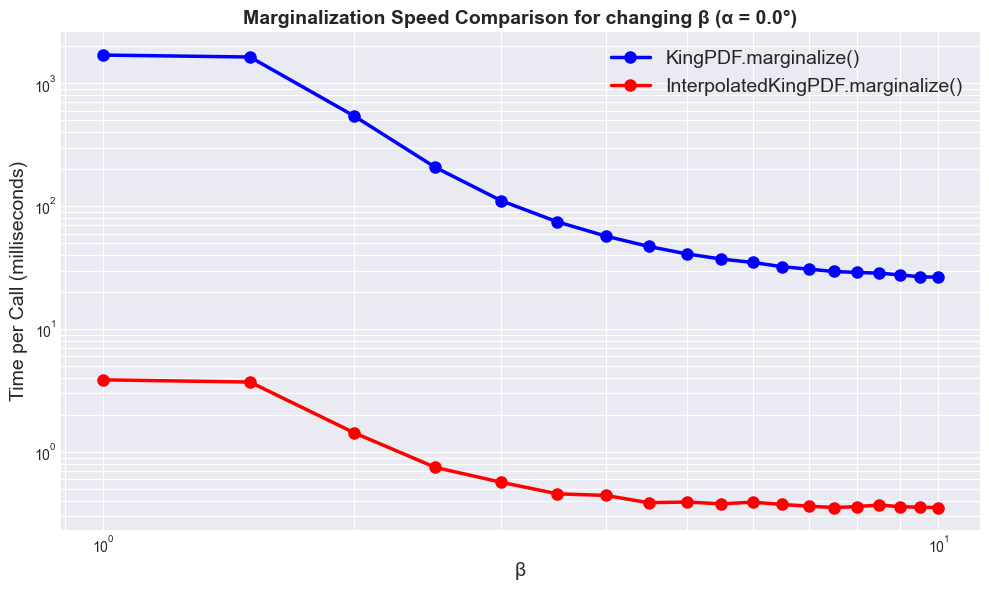


Speedup factor: 163.3x (median)


In [13]:
# Speed benchmark for marginalize() method
alpha = np.deg2rad(1)
betas_test = np.arange(1, 10.5, 0.5)
time_direct_marg = []
time_interp_marg = []

print("Benchmarking marginalize() evaluation speed...")
print("β | Direct (ms) | Interp (ms) | Speedup")
print("-" * 55)

for beta in betas_test:
    n_trials = 10
    
    # Time direct method
    t_direct = timeit(lambda: k.marginalize(0, alpha, beta), number=n_trials) / n_trials * 1000
    time_direct_marg.append(t_direct)
    
    # Time interpolated method
    t_interp = timeit(lambda: ik.marginalize(0, alpha, beta), number=n_trials) / n_trials * 1000
    time_interp_marg.append(t_interp)
    
    speedup = t_direct / t_interp
    print(f"{beta:7.2f} | {t_direct:11.2f} | {t_interp:11.2f} | {speedup:7.1f}x")

# Plot results
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(betas_test, time_direct_marg, 'o-', linewidth=2.5, markersize=8,
        label='KingPDF.marginalize()', color='blue')
ax.plot(betas_test, time_interp_marg, 'o-', linewidth=2.5, markersize=8,
        label='InterpolatedKingPDF.marginalize()', color='red')
ax.set_xlabel('β', fontsize=14)
ax.set_ylabel('Time per Call (milliseconds)', fontsize=14)
ax.set_title(f'Marginalization Speed Comparison for changing β (α = {alpha:.1f}°)', fontsize=14, fontweight='bold')
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend(fontsize=14)
ax.grid(alpha=1, which='both')
plt.tight_layout()
plt.show()

print(f"\nSpeedup factor: {np.median([time_direct_marg[i]/time_interp_marg[i] for i in range(len(alphas_test))]):.1f}x (median)")

## Summary

This notebook demonstrated:

1. **KingPDF Basics**
   - The PDF has two parameters: α (width) and β (tail shape)
   - Larger α = wider PSF (worse resolution)
   - Larger β = steeper/lighter tails
   
2. **Comparison with Rayleigh**
   - King provides more flexibility than Rayleigh
   - The β parameter allows control of tail behavior
   
3. **InterpolatedKingPDF**
   - 10-100× speedup for normalization calculations
   - < 0.1% error in most cases
   - Small memory footprint (~3 MB)
   
4. **Signal-Subtracted Likelihood**
   - `marginalize()` integrates over RA to get declination profile
   - Used in point source likelihood calculations
   - Also benefits from interpolation speedup

For most applications, **use `InterpolatedKingPDF`** unless you need extreme accuracy or have very unusual parameter ranges.